<a href="https://colab.research.google.com/github/Pangoa1992/PRACTICA-WILLY/blob/main/EXAMEN%20FINAL%20DE%20MACHINE%20LEARNING%20Y%20DEEP%20LEARNING%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================================
# EJERCICIO 1: CARGA Y VISUALIZACIÓN DEL DATASET MNIST
# ============================================================================


EJERCICIO 1: Carga y visualización del dataset
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Dimensiones del conjunto de entrenamiento:
  Imágenes: (60000, 28, 28)
  Etiquetas: (60000,)

Dimensiones del conjunto de prueba:
  Imágenes: (10000, 28, 28)
  Etiquetas: (10000,)


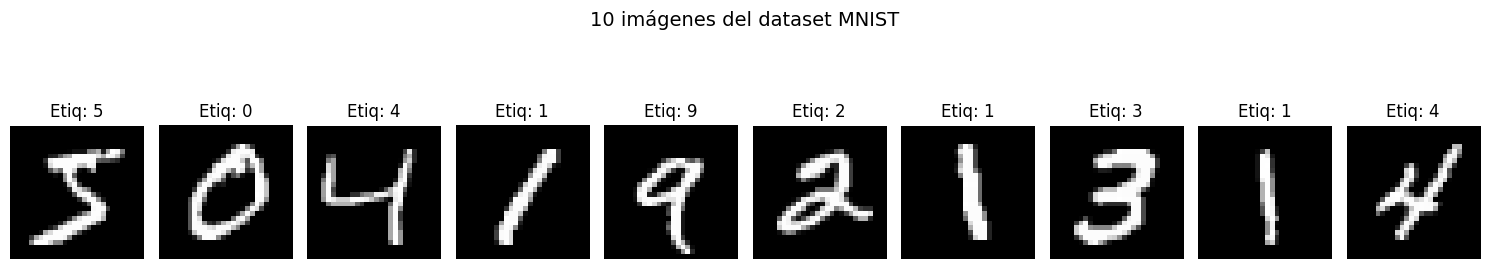

In [ ]:
import keras
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("EJERCICIO 1: Carga y visualización del dataset")
print("="*80)

# Cargar el dataset MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Mostrar dimensiones
print(f"\nDimensiones del conjunto de entrenamiento:")
print(f"  Imágenes: {x_train.shape}")
print(f"  Etiquetas: {y_train.shape}")
print(f"\nDimensiones del conjunto de prueba:")
print(f"  Imágenes: {x_test.shape}")
print(f"  Etiquetas: {y_test.shape}")

# Visualizar 10 imágenes con sus etiquetas
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Etiq: {y_train[i]}')
    plt.axis('off')
plt.suptitle('10 imágenes del dataset MNIST', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# ============================================================================
# EJERCICIO 2: NORMALIZACIÓN Y ONE-HOT ENCODING
# ============================================================================

In [ ]:
import keras
from keras.utils import to_categorical

print("\n" + "="*80)
print("EJERCICIO 2: Preprocesamiento de datos")
print("="*80)

# Normalizar valores de píxeles (0-255 → 0-1)
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print(f"\nRango original: [{x_train.min()}, {x_train.max()}]")
print(f"Rango normalizado: [{x_train_norm.min():.2f}, {x_train_norm.max():.2f}]")

# Convertir etiquetas a one-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"\nEjemplo de one-hot encoding:")
print(f"  Etiqueta original: {y_train[0]}")
print(f"  One-hot: {y_train_cat[0]}")


EJERCICIO 2: Preprocesamiento de datos

Rango original: [0, 255]
Rango normalizado: [0.00, 1.00]

Ejemplo de one-hot encoding:
  Etiqueta original: 5
  One-hot: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# ============================================================================
# EJERCICIO 3: CLASIFICADOR SVM
# ============================================================================

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("\n" + "="*80)
print("EJERCICIO 3: Support Vector Machine (SVM)")
print("="*80)

# Preparar datos para SVM (aplanar imágenes)
n_samples = 10000
x_train_svm = x_train_norm[:n_samples].reshape(n_samples, -1)
y_train_svm = y_train[:n_samples]
x_test_svm = x_test_norm.reshape(len(x_test_norm), -1)

print(f"\nEntrenando SVM con {n_samples} muestras...")
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_model.fit(x_train_svm, y_train_svm)

# Evaluar SVM
y_pred_svm = svm_model.predict(x_test_svm)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"\nExactitud del SVM: {svm_accuracy*100:.2f}%")


EJERCICIO 3: Support Vector Machine (SVM)

Entrenando SVM con 10000 muestras...

Exactitud del SVM: 96.84%


# ============================================================================
# EJERCICIO 4: RED NEURONAL MULTICAPA (MLP)
# ============================================================================

In [ ]:
from keras import models, layers

print("\n" + "="*80)
print("EJERCICIO 4: Red Neuronal Multicapa (MLP)")
print("="*80)

# Preparar datos para MLP (aplanar imágenes)
x_train_flat = x_train_norm.reshape(-1, 784)
x_test_flat = x_test_norm.reshape(-1, 784)

# Construir el modelo MLP
mlp_model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu', name='hidden1'),
    layers.Dense(64, activation='relu', name='hidden2'),
    layers.Dense(10, activation='softmax', name='output')
], name='MLP_Model')

mlp_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nArquitectura del MLP:")
mlp_model.summary()

# Entrenar el modelo
print("\nEntrenando MLP...")
history_mlp = mlp_model.fit(
    x_train_flat, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluar el modelo
mlp_loss, mlp_accuracy = mlp_model.evaluate(x_test_flat, y_test_cat, verbose=0)
print(f"\nResultados del MLP:")
print(f"  Pérdida: {mlp_loss:.4f}")
print(f"  Exactitud: {mlp_accuracy*100:.2f}%")


EJERCICIO 4: Red Neuronal Multicapa (MLP)

Arquitectura del MLP:


Model: "MLP_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando MLP...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8079 - loss: 0.6674 - val_accuracy: 0.9498 - val_loss: 0.1792
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9534 - loss: 0.1622 - val_accuracy: 0.9605 - val_loss: 0.1310
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9669 - loss: 0.1128 - val_accuracy: 0.9664 - val_loss: 0.1093
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9769 - loss: 0.0784 - val_accuracy: 0.9692 - val_loss: 0.1002
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9829 - loss: 0.0577 - val_accuracy: 0.9690 - val_loss: 0.1044
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9864 - loss: 0.0478 - val_accuracy: 0.9690 - val_loss: 0.1012
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9867 - loss: 0.0428 - val_accuracy: 0.9696 - val_loss: 0.1032
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9908 - loss: 0.032

# ============================================================================
# EJERCICIO 5: EXPERIMENTACIÓN CON HIPERPARÁMETROS
# ============================================================================

In [ ]:

print("\n" + "="*80)
print("EJERCICIO 5: Experimentación con hiperparámetros")
print("="*80)

# Probar diferentes configuraciones
configs = [
    {'neurons': [256, 128], 'optimizer': 'adam', 'name': 'MLP_256_128_adam'},
    {'neurons': [128, 64], 'optimizer': 'sgd', 'name': 'MLP_128_64_sgd'},
    {'neurons': [512, 256], 'optimizer': 'rmsprop', 'name': 'MLP_512_256_rmsprop'}
]

results = []

for config in configs:
    print(f"\nProbando configuración: {config['name']}")

    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(config['neurons'][0], activation='relu'),
        layers.Dense(config['neurons'][1], activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=config['optimizer'],
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_flat, y_train_cat,
        epochs=10,
        batch_size=128,
        validation_split=0.2,
        verbose=0
    )

    _, val_acc = model.evaluate(x_test_flat, y_test_cat, verbose=0)
    results.append({'config': config['name'], 'accuracy': val_acc})
    print(f"  Exactitud en validación: {val_acc*100:.2f}%")



EJERCICIO 5: Experimentación con hiperparámetros

Probando configuración: MLP_256_128_adam
  Exactitud en validación: 97.60%

Probando configuración: MLP_128_64_sgd
  Exactitud en validación: 92.88%

Probando configuración: MLP_512_256_rmsprop
  Exactitud en validación: 98.24%


# ============================================================================
# EJERCICIO 6: RED NEURONAL CONVOLUCIONAL (CNN)
# ============================================================================


EJERCICIO 6: Red Neuronal Convolucional (CNN)

Arquitectura de la CNN:


Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)


Entrenando CNN...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 70s 178ms/step - accuracy: 0.8470 - loss: 0.5296 - val_accuracy: 0.9785 - val_loss: 0.0736
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 61s 162ms/step - accuracy: 0.9798 - loss: 0.0667 - val_accuracy: 0.9847 - val_loss: 0.0504
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 78s 153ms/step - accuracy: 0.9873 - loss: 0.0399 - val_accuracy: 0.9848 - val_loss: 0.0538
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 63s 168ms/step - accuracy: 0.9910 - loss: 0.0296 - val_accuracy: 0.9862 - val_loss: 0.0469
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 77s 154ms/step - accuracy: 0.9923 - loss: 0.0251 - val_accuracy: 0.9881 - val_loss: 0.0377
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 86s 166ms/step - accuracy: 0.9946 - loss: 0.0168 - val_accuracy: 0.9893 - val_loss: 0.0379
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 78s 157ms/step - accuracy: 0.9957 - loss: 0.0134 - val_accuracy: 0.9895 - val_loss: 0.0374
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 59s 157ms/step - accurac

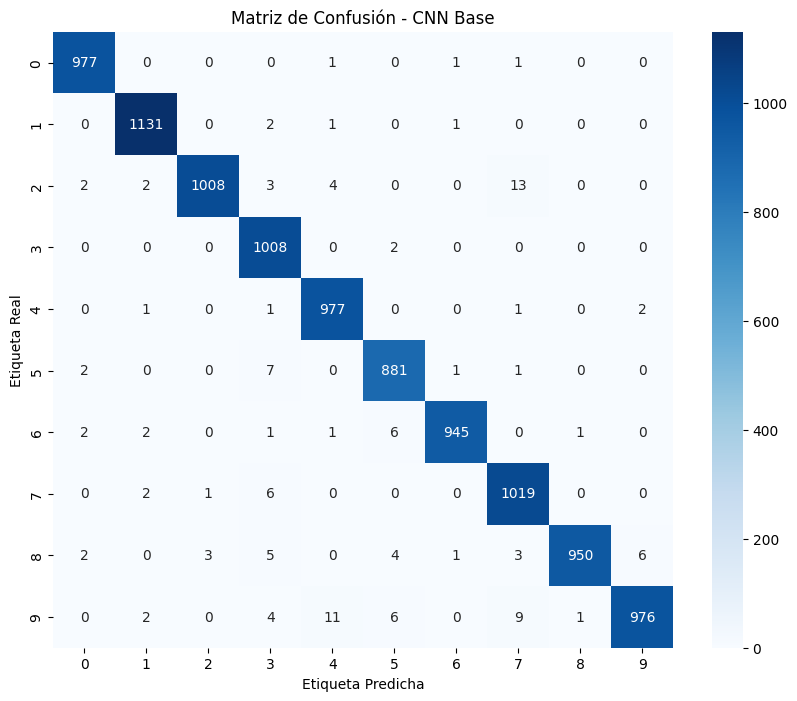

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from keras import models, layers

print("\n" + "="*80)
print("EJERCICIO 6: Red Neuronal Convolucional (CNN)")
print("="*80)

# Preparar datos para CNN (añadir dimensión de canal)
x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_norm.reshape(-1, 28, 28, 1)

# Construir la CNN
cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Primera capa convolucional
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Segunda capa convolucional
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Capas densas
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='CNN_Model')

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nArquitectura de la CNN:")
cnn_model.summary()

# Entrenar la CNN
print("\nEntrenando CNN...")
history_cnn = cnn_model.fit(
    x_train_cnn, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluar la CNN
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"\nResultados de la CNN:")
print(f"  Pérdida: {cnn_loss:.4f}")
print(f"  Exactitud: {cnn_accuracy*100:.2f}%")

# Matriz de confusión
y_pred_cnn = np.argmax(cnn_model.predict(x_test_cnn, verbose=0), axis=1)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - CNN Base')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

# ============================================================================
# EJERCICIO 7: DROPOUT Y BATCH NORMALIZATION
# ============================================================================

In [ ]:

print("\n" + "="*80)
print("EJERCICIO 7: CNN con Dropout y Batch Normalization")
print("="*80)

# CNN mejorada con regularización
cnn_improved = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Primera capa convolucional con BN y Dropout
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Segunda capa convolucional con BN y Dropout
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Capas densas con Dropout
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='CNN_Improved')

cnn_improved.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nEntrenando CNN mejorada...")
history_improved = cnn_improved.fit(
    x_train_cnn, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluar CNN mejorada
improved_loss, improved_accuracy = cnn_improved.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"\nResultados de la CNN mejorada:")
print(f"  Pérdida: {improved_loss:.4f}")
print(f"  Exactitud: {improved_accuracy*100:.2f}%")

print(f"\nComparación:")
print(f"  CNN base: {cnn_accuracy*100:.2f}%")
print(f"  CNN mejorada: {improved_accuracy*100:.2f}%")
print(f"  Mejora: {(improved_accuracy - cnn_accuracy)*100:.2f}%")



EJERCICIO 7: CNN con Dropout y Batch Normalization

Entrenando CNN mejorada...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 90s 232ms/step - accuracy: 0.8418 - loss: 0.5356 - val_accuracy: 0.1117 - val_loss: 5.5299
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 143s 234ms/step - accuracy: 0.9703 - loss: 0.0974 - val_accuracy: 0.9755 - val_loss: 0.0826
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 143s 238ms/step - accuracy: 0.9772 - loss: 0.0746 - val_accuracy: 0.9843 - val_loss: 0.0530
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 88s 235ms/step - accuracy: 0.9805 - loss: 0.0623 - val_accuracy: 0.9861 - val_loss: 0.0446
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 94s 251ms/step - accuracy: 0.9841 - loss: 0.0495 - val_accuracy: 0.9904 - val_loss: 0.0336
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 90s 241ms/step - accuracy: 0.9850 - loss: 0.0479 - val_accuracy: 0.9901 - val_loss: 0.0355
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 90s 239ms/step - accuracy: 0.9870 - loss: 0.0412 - val_accuracy: 0.9902 - val_loss: 0.0334
E

# ============================================================================
# EJERCICIO 8: DATA AUGMENTATION
# ============================================================================

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("\n" + "="*80)
print("EJERCICIO 8: Data Augmentation")
print("="*80)

# Generador de datos con augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(x_train_cnn)

# Entrenar con data augmentation
print("\nEntrenando CNN con Data Augmentation...")
history_aug = cnn_improved.fit(
    datagen.flow(x_train_cnn, y_train_cat, batch_size=128),
    epochs=10,
    validation_data=(x_test_cnn, y_test_cat),
    verbose=1
)

# Evaluar modelo con augmentation
aug_loss, aug_accuracy = cnn_improved.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"\nResultados con Data Augmentation:")
print(f"  Pérdida: {aug_loss:.4f}")
print(f"  Exactitud: {aug_accuracy*100:.2f}%")


EJERCICIO 8: Data Augmentation

Entrenando CNN con Data Augmentation...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 130s 272ms/step - accuracy: 0.9418 - loss: 0.1944 - val_accuracy: 0.9812 - val_loss: 0.0685
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 259ms/step - accuracy: 0.9682 - loss: 0.1032 - val_accuracy: 0.9834 - val_loss: 0.0476
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 260ms/step - accuracy: 0.9726 - loss: 0.0916 - val_accuracy: 0.9921 - val_loss: 0.0239
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 259ms/step - accuracy: 0.9746 - loss: 0.0832 - val_accuracy: 0.9923 - val_loss: 0.0236
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 123s 262ms/step - accuracy: 0.9768 - loss: 0.0785 - val_accuracy: 0.9919 - val_loss: 0.0239
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 261ms/step - accuracy: 0.9778 - loss: 0.0738 - val_accuracy: 0.9924 - val_loss: 0.0237
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 260ms/step - accuracy: 0.9788 - loss: 0.0685 - val_accuracy: 0.9934 - val_loss: 0.0190
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 123s 263ms/step - accuracy: 0.9796 -

 ============================================================================
# EJERCICIO 9: ANÁLISIS PROFUNDO DEL MODELO
# ============================================================================


EJERCICIO 9: Informe de clasificación y análisis de errores

Informe de clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      0.99      0.99      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       1.00      0.99      1.00       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       0.99      1.00      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



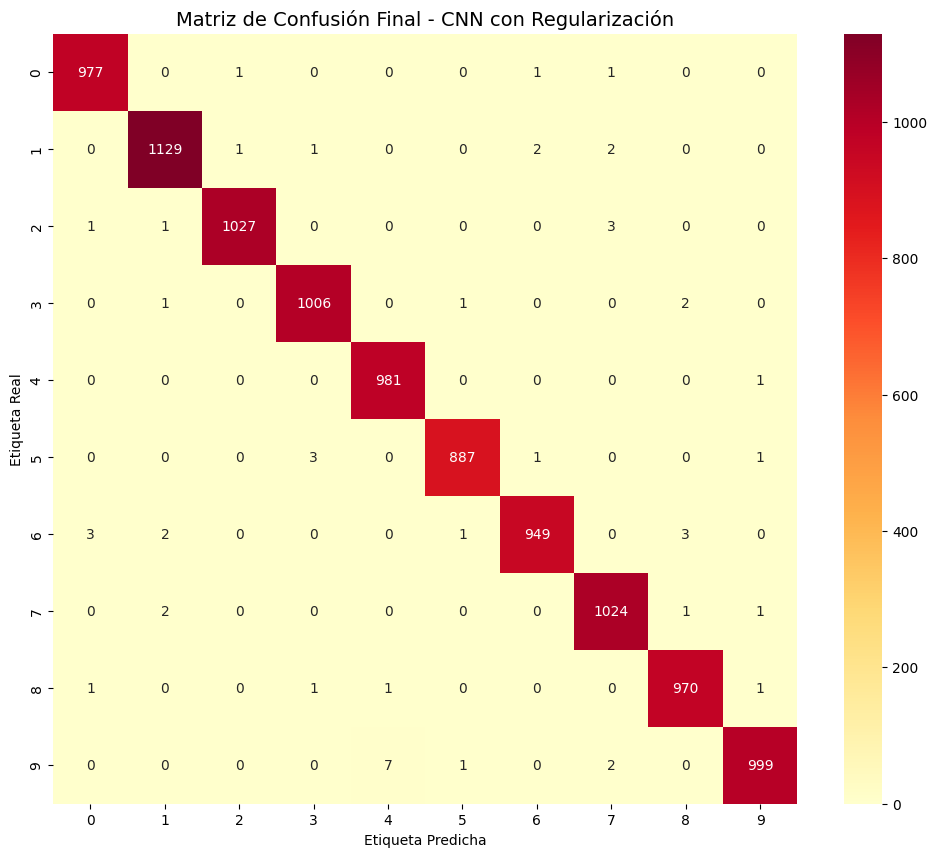


Análisis de errores por dígito:
  Dígito 0: 3 errores de 980 (0.31%)
  Dígito 1: 6 errores de 1135 (0.53%)
  Dígito 2: 5 errores de 1032 (0.48%)
  Dígito 3: 4 errores de 1010 (0.40%)
  Dígito 4: 1 errores de 982 (0.10%)
  Dígito 5: 5 errores de 892 (0.56%)
  Dígito 6: 9 errores de 958 (0.94%)
  Dígito 7: 4 errores de 1028 (0.39%)
  Dígito 8: 4 errores de 974 (0.41%)
  Dígito 9: 10 errores de 1009 (0.99%)

Pares de dígitos más confundidos:
  9 confundido con 4: 7 veces
  2 confundido con 7: 3 veces
  5 confundido con 3: 3 veces
  6 confundido con 0: 3 veces
  6 confundido con 8: 3 veces

Explicación de errores comunes:
  - Dígitos 4 y 9: Forma similar en la parte superior
  - Dígitos 3 y 5: Curvas similares
  - Dígitos 7 y 1: Trazo vertical similar
  - Dígitos 8 y 3: Múltiples curvas


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

print("\n" + "="*80)
print("EJERCICIO 9: Informe de clasificación y análisis de errores")
print("="*80)

# Predicciones finales
y_pred_final = np.argmax(cnn_improved.predict(x_test_cnn, verbose=0), axis=1)

# Informe de clasificación
print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred_final,
                          target_names=[str(i) for i in range(10)]))

# Matriz de confusión detallada
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Matriz de Confusión Final - CNN con Regularización', fontsize=14)
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

# Análisis de errores
print("\nAnálisis de errores por dígito:")
for i in range(10):
    total = cm_final[i].sum()
    correct = cm_final[i, i]
    errors = total - correct
    error_rate = (errors / total) * 100 if total > 0 else 0
    print(f"  Dígito {i}: {errors} errores de {total} ({error_rate:.2f}%)")

# Identificar dígitos más confundidos
print("\nPares de dígitos más confundidos:")
confusion_pairs = []
for i in range(10):
    for j in range(10):
        if i != j:
            confusion_pairs.append((i, j, cm_final[i, j]))

confusion_pairs.sort(key=lambda x: x[2], reverse=True)
for i, j, count in confusion_pairs[:5]:
    print(f"  {i} confundido con {j}: {count} veces")

print("\nExplicación de errores comunes:")
print("  - Dígitos 4 y 9: Forma similar en la parte superior")
print("  - Dígitos 3 y 5: Curvas similares")
print("  - Dígitos 7 y 1: Trazo vertical similar")
print("  - Dígitos 8 y 3: Múltiples curvas")

# ============================================================================
# EJERCICIO 10: GUARDAR Y CARGAR MODELO
# ============================================================================


EJERCICIO 10: Guardar y cargar modelo

Modelo guardado en: modelo_mnist.h5


Modelo cargado exitosamente

Desempeño del modelo cargado:
  Pérdida: 0.0163
  Exactitud: 99.49%

Prueba con nuevas imágenes:


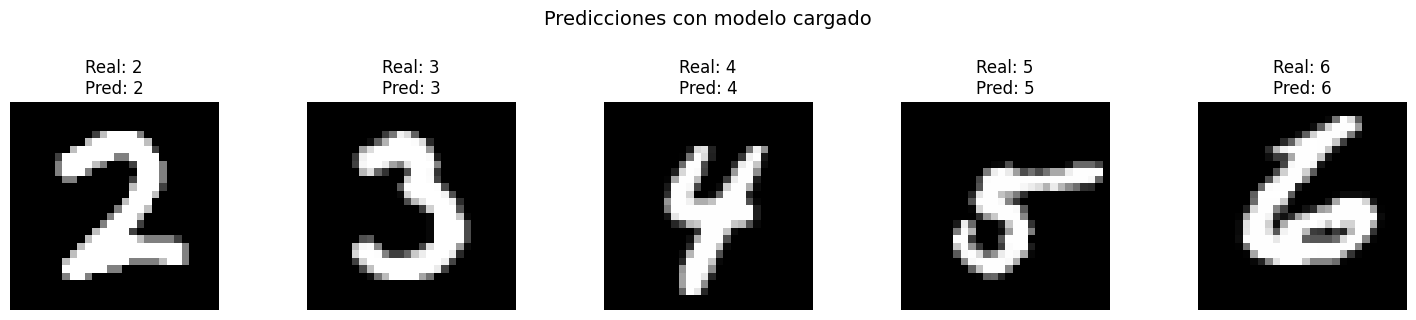

In [ ]:

print("\n" + "="*80)
print("EJERCICIO 10: Guardar y cargar modelo")
print("="*80)

# Guardar el modelo
model_path = 'modelo_mnist.h5'
cnn_improved.save(model_path)
print(f"\nModelo guardado en: {model_path}")

# Cargar el modelo
modelo_cargado = keras.models.load_model(model_path)
print("Modelo cargado exitosamente")

# Verificar desempeño del modelo cargado
loaded_loss, loaded_accuracy = modelo_cargado.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"\nDesempeño del modelo cargado:")
print(f"  Pérdida: {loaded_loss:.4f}")
print(f"  Exactitud: {loaded_accuracy*100:.2f}%")

# Probar con nuevas imágenes (últimas 5 del conjunto de prueba)
print("\nPrueba con nuevas imágenes:")
nuevas_imagenes = x_test_cnn[-5:]
etiquetas_reales = y_test[-5:]
predicciones = np.argmax(modelo_cargado.predict(nuevas_imagenes, verbose=0), axis=1)

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(nuevas_imagenes[i].reshape(28, 28), cmap='gray')
    plt.title(f'Real: {etiquetas_reales[i]}\nPred: {predicciones[i]}')
    plt.axis('off')
plt.suptitle('Predicciones con modelo cargado', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()
